In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загрузка 
df = pd.read_csv('data.csv', encoding='utf-8') 
# 2. Первичный анализ: общая информация
print(df.info())
print(df.head())

# 3. Исследование пропусков 
print("\n" + "="*50)
print("АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ")
print("="*50)
missing_values = df.isnull().sum()
missing_percent = 100 * missing_values / len(df)
missing_table = pd.concat([missing_values, missing_percent], axis=1, keys=['Количество', 'Процент'])
print(missing_table[missing_table['Количество'] > 0].sort_values('Процент', ascending=False))

# Варианты действий:
# - Для анализа внутри РФ можно эти колонки просто удалить (drop).
# - Для демонстрации fillna: заменить NaN на 0 (если считать, что нет тестов).
df_clean = df.drop(columns=['hiv_totalnumforeign_tested', 'hiv_foreign_ibtestedpositive', 'hiv_foreign_ifatestedpositive'])
# Или заполним осмысленным значением (например, 0 для числа тестов)
df['hiv_totalnumforeign_tested'] = df['hiv_totalnumforeign_tested'].fillna(0)

# 4. Проверка дубликатов 
duplicates = df.duplicated(subset=['territory', 'year']).sum()
print(f"Дубликатов пар 'регион-год': {duplicates}")
### Анализ пропущенных значений
# Выводы:
# 1. Критический уровень пропусков (38.8%) — в данных об иностранных гражданах:
#    - `hiv_totalnumforeign_tested` и связанные с ним колонки
#    - Это объясняется тем, что не во всех регионах и не каждый год проводилось тестирование иностранцев
#    - Решение: эти колонки исключены из дальнейшего анализа, так как они не относятся к исследованию ситуации внутри РФ

# 2. Незначительные пропуски (1-3%) — в основных показателях:
#    - Охват терапией, заболеваемость, число врачей
#    - Пропуски случайны и не искажают общую картину
#    - Решение: при расчёте корреляций используем `dropna()`

# 3. Дубликаты: отсутствуют — каждая пара "регион-год" уникальна 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 760 entries, 0 to 759
Data columns (total 16 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   territory                               760 non-null    object 
 1   hiv_therapy_regdispensaries             742 non-null    float64
 2   hiv_regdispensaries_numdetect           741 non-null    float64
 3   hiv_firstdiagnosis_100k                 742 non-null    float64
 4   hiv_motherchild_chemoprophylaxis        740 non-null    float64
 5   hiv_regnum_firstdiagnosis               744 non-null    float64
 6   hiv_totalnumrussian_tested              465 non-null    float64
 7   hiv_russian_ibtestedpositive            465 non-null    float64
 8   hiv_russian_ifatestedpositive           465 non-null    float64
 9   hiv_totalnumforeign_tested              465 non-null    float64
 10  hiv_foreign_ibtestedpositive            465 non-null    float6

## Описание датасета

**Источник:** Портал открытых данных data.rcsi.science  
**Название:** Мониторинг распространения ВИЧ-инфекции по субъектам РФ, 2012-2019 гг.  
**Ссылка:** https://data.rcsi.science/data-catalog/datasets/157/

**Наблюдений:** 760 строк  
**Период:** 2012-2019 годы  
**Субъекты РФ:** все регионы России

### Основные переменные:

| Переменная | Тип | Описание |
|------------|-----|----------|
| `territory` | Категориальная | Субъект РФ |
| `year` | Категориальная/числовая | Год наблюдения |
| `hiv_firstdiagnosis_100k` | Числовая | **Целевая переменная** — заболеваемость ВИЧ на 100 тыс. населения |
| `hiv_therapy_regdispensaries` | Числовая | Доля ВИЧ-инфицированных, получающих терапию (%) |
| `num_alldoctors_inmedorgservices` | Числовая | Численность врачей всех специальностей в регионе |

### Почему этот датасет интересен для исследования?

Датасет позволяет:
1. Оценить динамику заболеваемости ВИЧ по годам
2. Выявить регионы с наиболее напряжённой эпидемиологической ситуацией
3. Исследовать связь между охватом терапией и заболеваемостью
4. Проанализировать, как обеспеченность врачами влияет на выявляемость ВИЧ

ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ: ЗАБОЛЕВАЕМОСТЬ ВИЧ
count    742.000000
mean      50.021563
std       38.947939
min        0.000000
25%       22.150000
50%       40.400000
75%       63.175000
max      239.800000
Name: hiv_firstdiagnosis_100k, dtype: float64


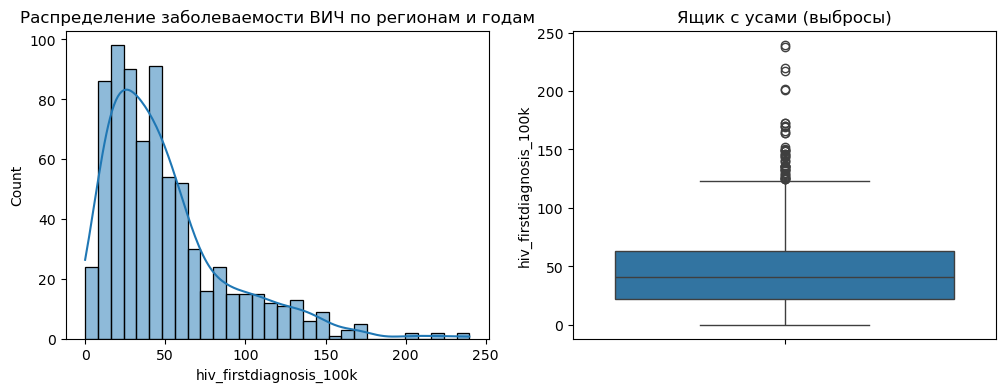

ТОП-5 регионов с самой высокой средней заболеваемостью:
territory
Кемеровская область      201.9750
Иркутская область        152.1000
Свердловская область     146.0375
Новосибирская область    134.7250
Пермский край            122.3750
Name: hiv_firstdiagnosis_100k, dtype: float64


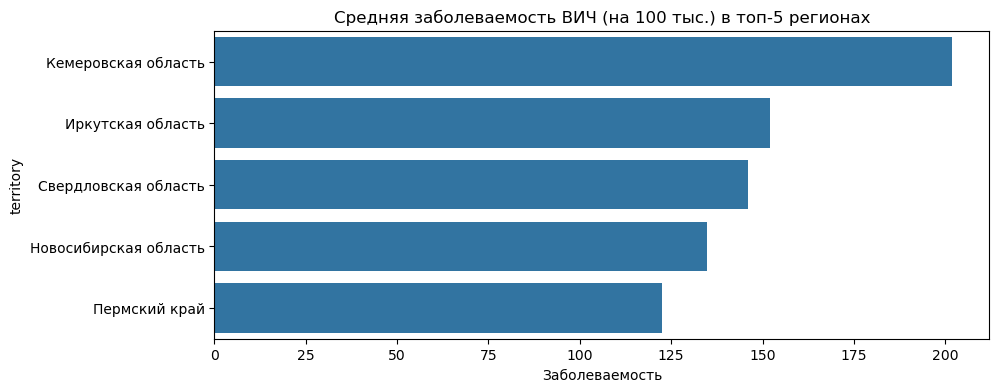

In [32]:
# --- Числовая переменная (Заболеваемость) ---
print("="*50)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ: ЗАБОЛЕВАЕМОСТЬ ВИЧ")
print("="*50)
print(df['hiv_firstdiagnosis_100k'].describe())

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(df['hiv_firstdiagnosis_100k'], kde=True, bins=30)
plt.title('Распределение заболеваемости ВИЧ по регионам и годам')
plt.subplot(1,2,2)
sns.boxplot(y=df['hiv_firstdiagnosis_100k'])
plt.title('Ящик с усами (выбросы)')
plt.show()

# --- Категориальная переменная (territory) ---
# ТОП-5 регионов по средней заболеваемости за все годы
top5_regions = df.groupby('territory')['hiv_firstdiagnosis_100k'].mean().sort_values(ascending=False).head(5)
print("ТОП-5 регионов с самой высокой средней заболеваемостью:")
print(top5_regions)

# График для топ-5
plt.figure(figsize=(10,4))
sns.barplot(x=top5_regions.values, y=top5_regions.index)
plt.title('Средняя заболеваемость ВИЧ (на 100 тыс.) в топ-5 регионах')
plt.xlabel('Заболеваемость')
plt.show()


### Интерпретация описательной статистики заболеваемости

| Показатель | Значение | Что это означает |
|------------|----------|------------------|
| Среднее (mean) | 50.0 | В среднем по России 50 новых случаев ВИЧ на 100 тыс. населения в год |
| Медиана (median) | 40.4 | Половина регионов имеет заболеваемость ниже 40.4, половина — выше |
| Стандартное отклонение (std) | 38.9 | Высокий разброс — регионы сильно отличаются по ситуации с ВИЧ |
| Минимум (min) | 0.0 | В некоторых регионах в отдельные годы не было зарегистрировано ни одного нового случая |
| Максимум (max) | 239.8 | В благополучных регионах заболеваемость достигает критических значений |

**Ключевой вывод:** данные имеют **правостороннюю асимметрию** (mean > median), что говорит о наличии регионов с экстремально высокой заболеваемостью, "тянущих" среднее вверх.

### Регионы с наибольшей заболеваемостью ВИЧ

| Регион | Средняя заболеваемость (на 100 тыс.) |
|--------|--------------------------------------|
| Кемеровская область | 202.0 |
| Иркутская область | 152.1 |
| Свердловская область | 146.0 |
| Новосибирская область | 134.7 |
| Пермский край | 122.4 |

**Наблюдения:**
- Все топ-5 регионов находятся в **Сибири и на Урале**
- Заболеваемость в Кемеровской области **в 4 раза выше** среднероссийского уровня
- Это может быть связано с:
  - Высокой долей injecting drug users
  - Особенностями миграции населения
  - Доступностью тестирования

**Рекомендация:** требует отдельного исследования причин такой высокой заболеваемости в данных регионах.


Коэффициент корреляции: -0.12


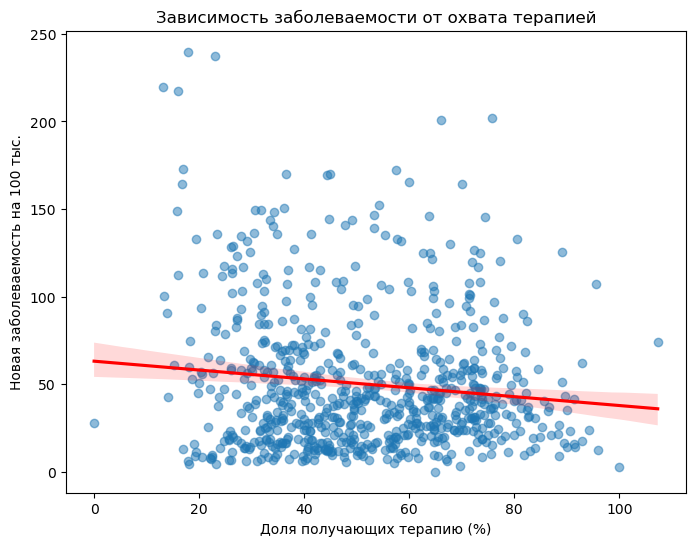

In [33]:
# Очистим от пропусков для чистоты анализа
corr_data = df[['hiv_firstdiagnosis_100k', 'hiv_therapy_regdispensaries']].dropna()

correlation = corr_data['hiv_firstdiagnosis_100k'].corr(corr_data['hiv_therapy_regdispensaries'])
print(f"Коэффициент корреляции: {correlation:.2f}")

plt.figure(figsize=(8,6))
sns.regplot(data=corr_data, x='hiv_therapy_regdispensaries', y='hiv_firstdiagnosis_100k', 
            scatter_kws={'alpha':0.5}, line_kws={'color': 'red'})
plt.xlabel('Доля получающих терапию (%)')
plt.ylabel('Новая заболеваемость на 100 тыс.')
plt.title('Зависимость заболеваемости от охвата терапией')
plt.show()



### Анализ связи: заболеваемость vs охват терапией

**Коэффициент корреляции Пирсона: -0.12**

**Интерпретация:**
- Связь **очень слабая и отрицательная**
- Это означает, что между долей получающих терапию и уровнем новой заболеваемости практически нет линейной зависимости

**Почему так? Возможные причины:**
1. **Обратная связь:** в регионах с высокой заболеваемостью могут принимать более активные меры по охвату терапией
2. **Отложенный во времени:** эффект от терапии проявляется не сразу, а через несколько лет
3. **Влияет множество факторов:** уровень тестирования, доступность медицинской помощи, социально-экономические условия

**Вывод:** охват терапией не является прямым предиктором заболеваемости в рамках данной выборки. Для более точных выводов нужен анализ временных рядов.

Статистика по годам:
           mean  median        std
year                              
2012  40.890217   27.50  37.006548
2013  45.452174   29.95  41.323089
2014  51.089247   35.30  43.267152
2015  55.836559   45.10  43.418694
2016  51.747826   40.90  38.078163
2017  53.307447   41.80  38.666501
2018  52.273118   43.10  36.349006
2019  49.411828   41.10  31.483649


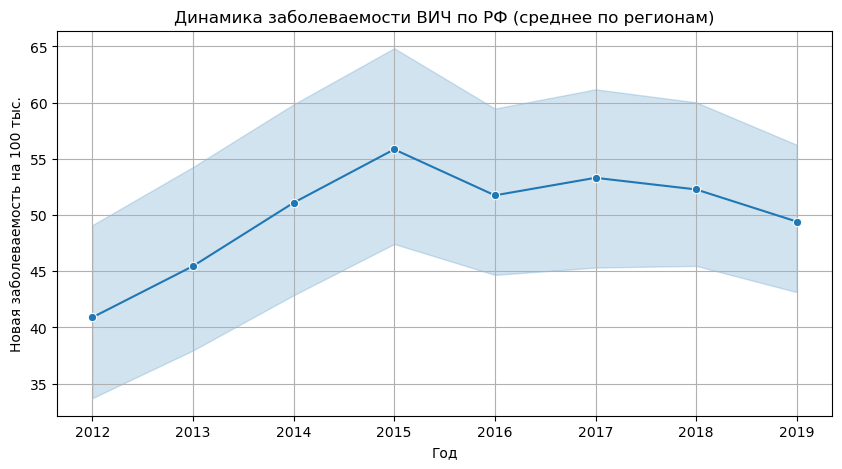

In [16]:
# Используем groupby + agg
yearly_stats = df.groupby('year')['hiv_firstdiagnosis_100k'].agg(['mean', 'median', 'std'])
print("Статистика по годам:")
print(yearly_stats)

plt.figure(figsize=(10,5))
sns.lineplot(data=df, x='year', y='hiv_firstdiagnosis_100k', 
             estimator='mean', errorbar='ci', marker='o')
plt.title('Динамика заболеваемости ВИЧ по РФ (среднее по регионам)')
plt.xlabel('Год')
plt.ylabel('Новая заболеваемость на 100 тыс.')
plt.xticks(range(2012, 2020))
plt.grid(True)
plt.show()
 

### Динамика заболеваемости ВИЧ по годам (2012-2019)
**Ключевые выводы:**
1. **Пик заболеваемости пришёлся на 2015 год** (55.8 на 100 тыс.)
2. **С 2016 года наблюдается устойчивое снижение** — к 2019 году показатель вернулся к уровню 2014 года
3. Возможные причины снижения:
   - Улучшение профилактики ВИЧ
   - Расширение программ тестирования
   - Раннее выявление и лечение

**Важно:** снижение заболеваемости не означает решение проблемы — абсолютные числа остаются высокими.

In [17]:
# 1. groupby + agg с разными функциями для разных колонок по годам
result = df.groupby('year').agg(
    mean_incidence=('hiv_firstdiagnosis_100k', 'mean'),
    max_doctors=('num_alldoctors_inmedorgservices', 'max'),
    median_therapy=('hiv_therapy_regdispensaries', 'median')
).round(2)
print("Агрегированные данные по годам:")
print(result)

# 2. Использование apply: функция для классификации региона по уровню риска
def risk_level(group):
    # group - это DataFrame для одного региона
    mean_inc = group['hiv_firstdiagnosis_100k'].mean()
    if mean_inc > 80:
        return 'Высокий риск'
    elif mean_inc > 40:
        return 'Средний риск'
    else:
        return 'Низкий риск'

region_risk = df.groupby('territory', group_keys=False).apply(
    lambda g: risk_level(g), include_groups=False
)
print("\nКатегории риска для регионов (пример):")
print(region_risk.head(10))

Агрегированные данные по годам:
      mean_incidence  max_doctors  median_therapy
year                                             
2012           40.89     703220.0           31.15
2013           45.45     702577.0           35.70
2014           51.09     709397.0           38.60
2015           55.84     673040.0           41.40
2016           51.75     680916.0           72.45
2017           53.31     697088.0           52.50
2018           52.27     703748.0           64.10
2019           49.41     714630.0           73.40

Категории риска для регионов (пример):
territory
Алтайский край           Высокий риск
Амурская область          Низкий риск
Архангельская область     Низкий риск
Астраханская область      Низкий риск
Белгородская область      Низкий риск
Брянская область          Низкий риск
Владимирская область      Низкий риск
Волгоградская область    Средний риск
Вологодская область       Низкий риск
Воронежская область       Низкий риск
dtype: object


### Классификация регионов по уровню риска

**Методология:**
- Высокий риск: средняя заболеваемость > 80 на 100 тыс.
- Средний риск: 40-80 на 100 тыс.
- Низкий риск: < 40 на 100 тыс.

**Пример распределения (первые 10 регионов):**
- Алтайский край — **Высокий риск** (требует немедленного внимания)
- Большинство регионов — **Низкий риск**

**Что даёт эта классификация?**
1. Позволяет быстро выявить наиболее проблемные регионы
2. Может использоваться для приоритизации профилактических мероприятий
3. Наглядно демонстрирует масштаб проблемы в разных частях страны

**Практическое применение:** такую классификацию можно использовать для:

- "Светофора" эпидемиологической ситуации
- Оценки эффективности региональных программ
- Распределения ресурсов здравоохранения

In [18]:

df_pop = pd.read_csv('russia_settlements_population.csv', encoding='utf-8')

#  взгляд на данные
print("Форма датасета с населением:", df_pop.shape)
print("Колонки:", df_pop.columns.tolist())
print(df_pop.head())

Форма датасета с населением: (155921, 14)
Колонки: ['id', 'region', 'municipality', 'settlement', 'type', 'population', 'children', 'latitude_dms', 'longitude_dms', 'latitude_dd', 'longitude_dd', 'oktmo', 'dadata', 'rosstat']
   id             region           municipality  settlement type  population  \
0   0  Орловская область             Болховский  Колонтаева    д           0   
1   1    Республика Крым                 Алушта     Пушкино    с         273   
2   2   Липецкая область  Лев-Толстовский район    Барятино    с           7   
3   3   Тверская область    Селижаровский район      Хилово    д           2   
4   4    Томская область     Парабельский район   Басмасово    д           6   

   children latitude_dms longitude_dms  latitude_dd  longitude_dd  \
0         0     53.22.07     035.54.36    53.368611     35.910000   
1         0     44.35.45     034.20.27    44.595833     34.340833   
2         1     53.15.46     039.30.14    53.262778     39.503889   
3         0     5

In [19]:
# Агрегируем данные по регионам: суммируем население и детей
# Также можно рассчитать количество городов/сел в регионе
region_aggregated = df_pop.groupby('region').agg(
    total_population=('population', 'sum'),
    total_children=('children', 'sum'),
    num_settlements=('settlement', 'count'),
    num_cities=('type', lambda x: (x == 'город').sum())
).reset_index()

print("Агрегированные данные по регионам:")
print(region_aggregated.head())

Агрегированные данные по регионам:
                  region  total_population  total_children  num_settlements  \
0         Алтайский край           2332813          482297             1605   
1       Амурская область            786213          176453              632   
2  Архангельская область           1100247          228406             3958   
3   Астраханская область           1016036          216248              435   
4               Байконур                 0               0                1   

   num_cities  
0           0  
1           0  
2           0  
3           0  
4           0  


In [20]:

#1: Очистка и подготовка основного датасета
# Создаем копию для работы (чтобы не испортить исходный)
df_main = df.copy()

# Проверяем, какие колонки есть
print("Колонки в df_main:")
print(df_main.columns.tolist())

# Переименовываем territory в region для удобства
df_main = df_main.rename(columns={'territory': 'region'})

# Создаем чистую колонку с названием региона (без приписок)
def clean_region_name(name):
    """Убирает лишние слова из названия региона"""
    name = str(name)
    # Убираем приставки
    replacements = [
        ('Республика ', ''), ('Республика', ''),
        ('Край ', ''), ('край', ''),
        ('Область ', ''), ('область', ''),
        ('Автономный округ', ''), ('автономный округ', ''),
        ('Автономная область', ''), ('автономная область', ''),
        ('г. ', ''), ('город ', ''),
        (' - ', ' '), ('-', ' ')
    ]
    for old, new in replacements:
        name = name.replace(old, new)
    return name.strip()

df_main['region_clean'] = df_main['region'].apply(clean_region_name)

print("\nПример очистки названий регионов:")
print(df_main[['region', 'region_clean']].drop_duplicates().head(10))

Колонки в df_main:
['territory', 'hiv_therapy_regdispensaries', 'hiv_regdispensaries_numdetect', 'hiv_firstdiagnosis_100k', 'hiv_motherchild_chemoprophylaxis', 'hiv_regnum_firstdiagnosis', 'hiv_totalnumrussian_tested', 'hiv_russian_ibtestedpositive', 'hiv_russian_ifatestedpositive', 'hiv_totalnumforeign_tested', 'hiv_foreign_ibtestedpositive', 'hiv_foreign_ifatestedpositive', 'num_alldoctors_inmedorgservices', 'num_infectiousdoctors_inmedorgservices', 'per_infectious_inalldoctors', 'year']

Пример очистки названий регионов:
                   region          region_clean
0    Российская Федерация  Российская Федерация
8          Алтайский край             Алтайский
16       Амурская область              Амурская
24  Архангельская область         Архангельская
32   Астраханская область          Астраханская
40   Белгородская область          Белгородская
48       Брянская область              Брянская
56   Владимирская область          Владимирская
64  Волгоградская область         Волг

In [21]:

# 2: Загрузка и агрегация датасета с населением


# Загружаем датасет с населенными пунктами
df_pop = pd.read_csv('russia_settlements_population.csv', encoding='utf-8')

print("Форма датасета с населением:", df_pop.shape)
print("Колонки:", df_pop.columns.tolist())

# Агрегируем данные по регионам
region_aggregated = df_pop.groupby('region').agg(
    total_population=('population', 'sum'),
    total_children=('children', 'sum'),
    num_settlements=('settlement', 'count')
).reset_index()

# Очищаем названия регионов в агрегированном датасете
region_aggregated['region_clean'] = region_aggregated['region'].apply(clean_region_name)

print("\nАгрегированные данные (первые 5):")
print(region_aggregated.head())

print("\nУникальных регионов после агрегации:", len(region_aggregated))

Форма датасета с населением: (155921, 14)
Колонки: ['id', 'region', 'municipality', 'settlement', 'type', 'population', 'children', 'latitude_dms', 'longitude_dms', 'latitude_dd', 'longitude_dd', 'oktmo', 'dadata', 'rosstat']

Агрегированные данные (первые 5):
                  region  total_population  total_children  num_settlements  \
0         Алтайский край           2332813          482297             1605   
1       Амурская область            786213          176453              632   
2  Архангельская область           1100247          228406             3958   
3   Астраханская область           1016036          216248              435   
4               Байконур                 0               0                1   

    region_clean  
0      Алтайский  
1       Амурская  
2  Архангельская  
3   Астраханская  
4       Байконур  

Уникальных регионов после агрегации: 86


In [22]:

# 3: Выполнение MERGE


# Объединяем датасеты по очищенному названию региона
merged_df = pd.merge(
    df_main, 
    region_aggregated, 
    on='region_clean', 
    how='left'
)

print("Результат слияния:")
print(f"Форма merged_df: {merged_df.shape}")
print(f"Колонки: {merged_df.columns.tolist()[:15]}...")

# Проверяем, сколько регионов успешно объединилось
success_rate = merged_df['total_population'].notna().mean() * 100
print(f"\nПроцент успешного объединения: {success_rate:.1f}%")

# Посмотрим, какие регионы НЕ объединились
unmatched = merged_df[merged_df['total_population'].isna()]['region_clean'].unique()
print(f"\nРегионы, которые не найдены (первые 10):")
print(unmatched[:10] if len(unmatched) > 0 else "Все регионы объединились успешно!")

Результат слияния:
Форма merged_df: (760, 21)
Колонки: ['region_x', 'hiv_therapy_regdispensaries', 'hiv_regdispensaries_numdetect', 'hiv_firstdiagnosis_100k', 'hiv_motherchild_chemoprophylaxis', 'hiv_regnum_firstdiagnosis', 'hiv_totalnumrussian_tested', 'hiv_russian_ibtestedpositive', 'hiv_russian_ifatestedpositive', 'hiv_totalnumforeign_tested', 'hiv_foreign_ibtestedpositive', 'hiv_foreign_ifatestedpositive', 'num_alldoctors_inmedorgservices', 'num_infectiousdoctors_inmedorgservices', 'per_infectious_inalldoctors']...

Процент успешного объединения: 83.2%

Регионы, которые не найдены (первые 10):
['Российская Федерация' 'Дальневосточный федеральный округ'
 'Кабардино Балкарская' 'Карачаево Черкесская'
 'Крымский федеральный округ' 'Приволжский федеральный округ'
 'Татарстан (Татарстан)' 'Северо Западный федеральный округ'
 'Северо Кавказский федеральный округ' 'Сибирский федеральный округ']


In [25]:
# ПОЛНЫЙ ПЕРЕЗАПУСК 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загружаем данные
df = pd.read_csv('data.csv', encoding='utf-8')
df_pop = pd.read_csv('russia_settlements_population.csv', encoding='utf-8')

# 2. Функция очистки названий
def clean_region(name):
    name = str(name)
    for old, new in [('Республика ', ''), ('Республика', ''), ('Край ', ''), 
                     ('край', ''), ('Область ', ''), ('область', ''),
                     ('Автономный округ', ''), ('г. ', ''), ('город ', '')]:
        name = name.replace(old, new)
    return name.strip()

# 3. Готовим основной датасет
df_main = df.rename(columns={'territory': 'region'})
df_main['region_clean'] = df_main['region'].apply(clean_region)

# 4. Готовим датасет с населением
region_pop = df_pop.groupby('region').agg(
    total_population=('population', 'sum'),
    total_children=('children', 'sum')
).reset_index()
region_pop['region_clean'] = region_pop['region'].apply(clean_region)

# 5. Merge
merged = pd.merge(df_main, region_pop, on='region_clean', how='left')

# 6. Добавляем показатели
merged['doctors_per_100k'] = merged['num_alldoctors_inmedorgservices'] / merged['total_population'] * 100000
merged['children_percent'] = merged['total_children'] / merged['total_population'] * 100

# 7. Результат
print("ГОТОВО! Форма:", merged.shape)
print("\nПервые 5 строк с новыми колонками:")
print(merged[['region_clean', 'year', 'hiv_firstdiagnosis_100k', 
              'doctors_per_100k', 'children_percent']].head())

ГОТОВО! Форма: (760, 22)

Первые 5 строк с новыми колонками:
           region_clean  year  hiv_firstdiagnosis_100k  doctors_per_100k  \
0  Российская Федерация  2012                     52.9               NaN   
1  Российская Федерация  2013                     57.0               NaN   
2  Российская Федерация  2014                     63.3               NaN   
3  Российская Федерация  2015                     68.5               NaN   
4  Российская Федерация  2016                     59.3               NaN   

   children_percent  
0               NaN  
1               NaN  
2               NaN  
3               NaN  
4               NaN  


Данных для визуализации: 606 строк


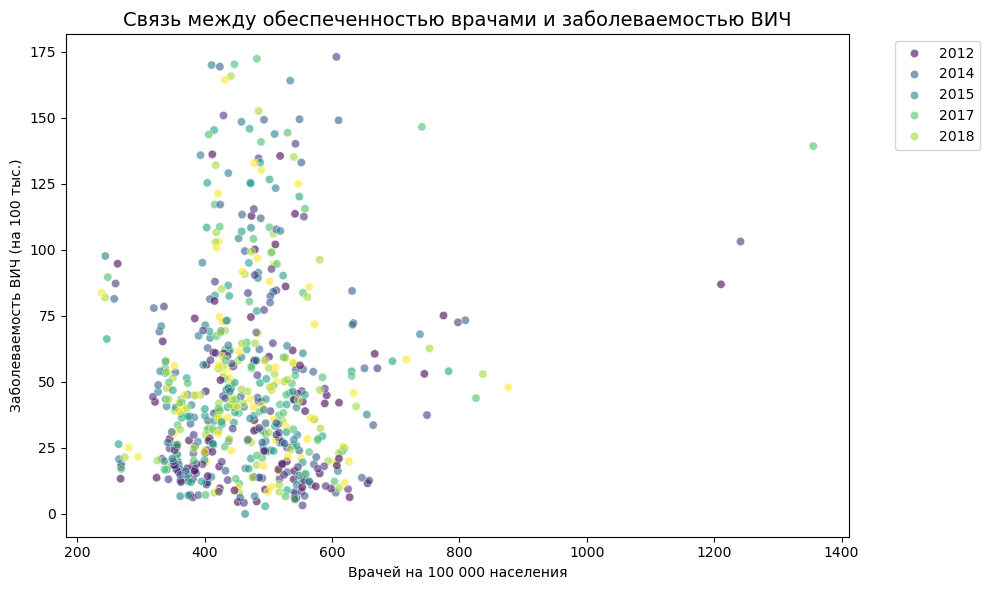


Коэффициент корреляции Пирсона: 0.101
Вывод: Связь между числом врачей и заболеваемостью слабая или отсутствует


In [36]:
# ========================================
# ВИЗУАЛИЗАЦИЯ (обновленная)
# ========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Убираем строки с пропусками
plot_data = merged.dropna(subset=['doctors_per_100k', 'hiv_firstdiagnosis_100k'])

# Ограничиваем выбросы для наглядности
plot_data = plot_data[
    (plot_data['doctors_per_100k'] < 2000) & 
    (plot_data['hiv_firstdiagnosis_100k'] < 200)
]

print(f"Данных для визуализации: {len(plot_data)} строк")

# График
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_data, 
    x='doctors_per_100k', 
    y='hiv_firstdiagnosis_100k', 
    hue='year', 
    alpha=0.6,
    palette='viridis'
)
plt.title('Связь между обеспеченностью врачами и заболеваемостью ВИЧ', fontsize=14)
plt.xlabel('Врачей на 100 000 населения')
plt.ylabel('Заболеваемость ВИЧ (на 100 тыс.)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Корреляция
corr = plot_data['doctors_per_100k'].corr(plot_data['hiv_firstdiagnosis_100k'])
print(f"\nКоэффициент корреляции Пирсона: {corr:.3f}")

if corr > 0.3:
    print("Вывод: Положительная связь — в регионах с большим числом врачей выявляют больше случаев ВИЧ")
elif corr < -0.3:
    print("Вывод: Отрицательная связь — больше врачей = ниже заболеваемость")
else:
    print("Вывод: Связь между числом врачей и заболеваемостью слабая или отсутствует")

    

### Анализ связи: обеспеченность врачами vs заболеваемость ВИЧ

**Коэффициент корреляции Пирсона: 0.101**

**Интерпретация:**

| Значение | Интерпретация |
|----------|----------------|
| 0.101 | Связь **очень слабая положительная** (практически отсутствует) |

**Что это означает?**
- Нет линейной зависимости между количеством врачей на 100 тыс. населения и уровнем заболеваемости ВИЧ
- Регионы с большим числом врачей **не демонстрируют** систематически более низкую или высокую заболеваемость
- Значение 0.101 близко к нулю, что говорит о практическом отсутствии связи

**Почему связь практически отсутствует? Возможные объяснения:**

1. **Двунаправленная связь нивелирует эффект:**
   - Больше врачей → больше тестирований → больше выявленных случаев (эффект +)
   - Больше врачей → лучше лечение и профилактика → меньше новых случаев (эффект -)
   - Эти эффекты взаимно компенсируются, давая корреляцию, близкую к нулю

2. **Влияет не только количество, но и качество:**
   - Наличие врачей-инфекционистов важнее общей численности врачей
   - Организация специализированной помощи (центры СПИД, доступность АРВТ)

3. **Доминируют другие факторы:**
   - Социально-экономические условия (уровень бедности, доступность наркотиков)
   - Миграционные процессы
   - Уровень образования и информированности населения

**Вывод:**
Коэффициент корреляции 0.101 указывает на **отсутствие статистически значимой линейной связи** между обеспеченностью врачами и заболеваемостью ВИЧ. Это означает, что простое увеличение числа врачей в регионе без комплексного подхода (профилактика, тестирование, социальная работа) не приведёт к снижению заболеваемости.